In [ ]:
# The Chief Product Officer has challenged the
# team to move beyond "activation theater"—optimizing metrics that look good
# but don't predict business outcomes. She wants evidence-based proof that
# your activation metrics actually correlate with long-term user retention and
# business value.
# Your assignment is to develop a comprehensive retention prediction model
# using 6 months of user behavior data. This analysis will inform a major product
# roadmap decision: whether to invest $300K in redesigning the onboarding
# experience or focus resources on improving post-activation engagement
# features.
# Leadership expects statistical rigor—they want correlation coefficients,
# significance testing, and confidence intervals, not just trend observations. Your
# retention prediction model will directly influence product strategy and
# engineering priorities for the next two quarters.

In [22]:
### correlation analysis 

In [23]:
import pandas as pd

df = pd.read_excel("data/growthtech_activation_retention_data.xlsx")
df.head()

,user_id,signup_date,acquisition_channel,account_setup_completed,first_project_created,team_invite_sent,premium_trial_started,total_sessions,retained_30_day,retained_90_day
0,U100000,2026-03-15,Paid Social,1,1,0,0,1,1,1
1,U100001,2026-05-03,Direct,1,1,0,0,12,1,1
2,U100002,2026-08-01,Content Marketing,1,1,0,1,8,1,1
3,U100003,2026-07-31,Referral,1,1,0,0,5,1,1
4,U100004,2026-05-18,Organic Search,1,0,0,1,5,1,0


In [24]:
n_distinct_users = df["user_id"].nunique()
n_rows = len(df)

print(f"Distinct users: {n_distinct_users}")
print(f"Dataset rows: {n_rows}")
print(f"One row per user: {n_distinct_users == n_rows}")

Distinct users: 1200
Dataset rows: 1200
One row per user: True


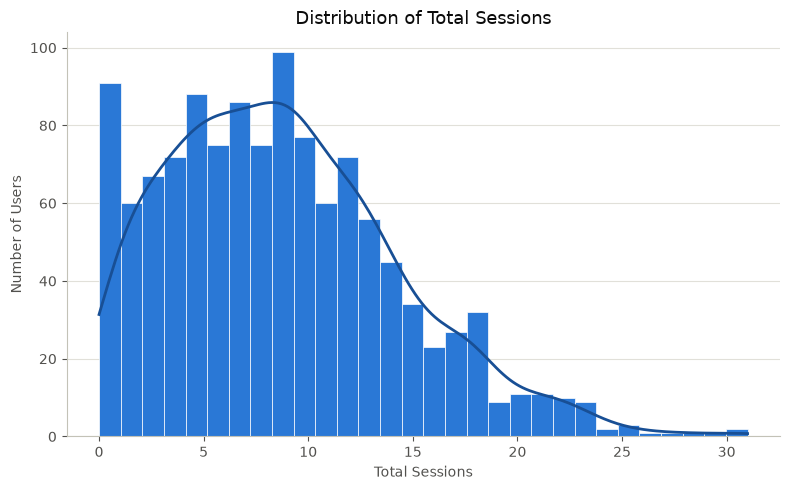

count    1200.000000
mean        8.802500
std         5.510638
min         0.000000
25%         5.000000
50%         8.000000
75%        12.000000
max        31.000000
Name: total_sessions, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

BLUE = "#2a78d6"
BLUE_DARK = "#184f95"
INK_SECONDARY = "#52514e"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

fig, ax = plt.subplots(figsize=(8, 5))

n_bins = 30
counts, bin_edges, _ = ax.hist(
    df["total_sessions"], bins=n_bins, color=BLUE, edgecolor="white", linewidth=0.5
)

kde = gaussian_kde(df["total_sessions"])
x_grid = np.linspace(df["total_sessions"].min(), df["total_sessions"].max(), 200)
density = kde(x_grid)

bin_width = bin_edges[1] - bin_edges[0]
density_scaled = density * len(df) * bin_width

ax.plot(x_grid, density_scaled, color=BLUE_DARK, linewidth=2)

ax.set_title("Distribution of Total Sessions", color="#0b0b0b", fontsize=13)
ax.set_xlabel("Total Sessions", color=INK_SECONDARY)
ax.set_ylabel("Number of Users", color=INK_SECONDARY)

ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(BASELINE)
ax.tick_params(colors=INK_SECONDARY)

plt.tight_layout()
plt.show()

print(df["total_sessions"].describe())

### Choosing a correlation coefficient

- `account_setup_completed`, `first_project_created`, `team_invite_sent`, `premium_trial_started` are all **binary** flags. Pearson correlation against a binary retention outcome reduces to the point-biserial coefficient, so it's the natural default for these.
- `total_sessions` is **right-skewed** (see the distribution plot above: long tail of highly engaged users). Pearson assumes a linear relationship and is sensitive to that skew/outliers, so **Spearman is the primary coefficient for `total_sessions`** — it uses ranks, so it only requires a monotonic relationship and isn't distorted by the tail.
- Pearson and Spearman are computed for every column below as a sanity check either way. For the binary steps they should be nearly identical; for `total_sessions` Spearman is the one to trust, with Pearson shown alongside for reference.

In [30]:
predictor_cols = [
    "account_setup_completed",
    "first_project_created",
    "team_invite_sent",
    "premium_trial_started",
    "total_sessions",
]
retention_cols = ["retained_30_day", "retained_90_day"]

corr_table = pd.DataFrame({
    (ret_col, method): df[predictor_cols].corrwith(df[ret_col], method=method)
    for ret_col in retention_cols
    for method in ["pearson", "spearman"]
})
corr_table.columns = pd.MultiIndex.from_tuples(corr_table.columns, names=["retention_window", "method"])
corr_table.sort_values(("retained_30_day", "spearman"), ascending=False)

retention_window        retained_30_day           retained_90_day          
method                          pearson  spearman         pearson  spearman
total_sessions                 0.518712  0.551091        0.592527  0.622231
team_invite_sent               0.274638  0.274638        0.324548  0.324548
premium_trial_started          0.264572  0.264572        0.254661  0.254661
first_project_created          0.160175  0.160175        0.193908  0.193908
account_setup_completed        0.030136  0.030136        0.014808  0.014808

### Is the correlation statistically significant?

Each coefficient above tests **H₀: ρ = 0** (no true correlation) vs **H₁: ρ ≠ 0**. `scipy.stats.pearsonr` / `spearmanr` return a p-value for this directly — no manual calculation needed.

With n = 1,200, the sample is large enough that even tiny correlations can come back p < 0.05 just because the estimate is precise, not because the effect is meaningful. So p-value alone isn't enough — **effect size** matters too. Rule of thumb (Cohen): |r| < 0.1 negligible, 0.1–0.3 small, 0.3–0.5 moderate, > 0.5 large.

The cell below reports, for every activation variable × retention window: the coefficient, its p-value, a 95% confidence interval (via Fisher z-transform), and a plain-language effect-size label.

In [31]:
from scipy.stats import pearsonr, spearmanr, norm


def effect_size_label(r):
    r = abs(r)
    if r < 0.1:
        return "negligible"
    elif r < 0.3:
        return "small"
    elif r < 0.5:
        return "moderate"
    else:
        return "large"


def fisher_ci(r, n, alpha=0.05):
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha / 2)
    lo, hi = z - z_crit * se, z + z_crit * se
    return np.tanh(lo), np.tanh(hi)


n = len(df)
rows = []
for ret_col in retention_cols:
    for pred_col in predictor_cols:
        r_p, p_p = pearsonr(df[pred_col], df[ret_col])
        r_s, p_s = spearmanr(df[pred_col], df[ret_col])
        ci_lo, ci_hi = fisher_ci(r_p, n)
        rows.append({
            "retention_window": ret_col,
            "predictor": pred_col,
            "pearson_r": r_p,
            "pearson_p": p_p,
            "pearson_95ci": f"[{ci_lo:.3f}, {ci_hi:.3f}]",
            "spearman_rho": r_s,
            "spearman_p": p_s,
            "significant (p<0.05)": p_p < 0.05,
            "effect_size": effect_size_label(r_p),
        })

significance_table = pd.DataFrame(rows).set_index(["retention_window", "predictor"])
significance_table

pearson_r      pearson_p  \
retention_window predictor                                           
retained_30_day  account_setup_completed   0.030136   2.969077e-01   
                 first_project_created     0.160175   2.420216e-08   
                 team_invite_sent          0.274638   3.300075e-22   
                 premium_trial_started     0.264572   1.140462e-20   
                 total_sessions            0.518712   1.291593e-83   
retained_90_day  account_setup_completed   0.014808   6.083378e-01   
                 first_project_created     0.193908   1.247773e-11   
                 team_invite_sent          0.324548   7.832412e-31   
                 premium_trial_started     0.254661   3.227884e-19   
                 total_sessions            0.592527  1.225650e-114   

                                             pearson_95ci  spearman_rho  \
retention_window predictor                                                
retained_30_day  account_setup_completed  [-0.026, 0.087]      0.030136   
                 first_project_created     [0.105, 0.215]      0.160175   
                 team_invite_sent          [0.221, 0.326]      0.274638   
                 premium_trial_started     [0.211, 0.316]      0.264572   
                 total_sessions            [0.476, 0.559]      0.551091   
retained_90_day  account_setup_completed  [-0.042, 0.071]      0.014808   
                 first_project_created     [0.139, 0.248]      0.193908   
                 team_invite_sent          [0.273, 0.374]      0.324548   
                 premium_trial_started     [0.201, 0.307]      0.254661   
                 total_sessions            [0.555, 0.628]      0.622231   

                                             spearman_p  significant (p<0.05)  \
retention_window predictor                                                      
retained_30_day  account_setup_completed   2.969077e-01                 False   
                 first_project_created     2.420216e-08                  True   
                 team_invite_sent          3.300075e-22                  True   
                 premium_trial_started     1.140462e-20                  True   
                 total_sessions            2.852200e-96                  True   
retained_90_day  account_setup_completed   6.083378e-01                 False   
                 first_project_created     1.247773e-11                  True   
                 team_invite_sent          7.832412e-31                  True   
                 premium_trial_started     3.227884e-19                  True   
                 total_sessions           1.527307e-129                  True   

                                         effect_size  
retention_window predictor                            
retained_30_day  account_setup_completed  negligible  
                 first_project_created         small  
                 team_invite_sent              small  
                 premium_trial_started         small  
                 total_sessions                large  
retained_90_day  account_setup_completed  negligible  
                 first_project_created         small  
                 team_invite_sent           moderate  
                 premium_trial_started         small  
                 total_sessions                large

### Summary of findings

**How to read the numbers:**
- A correlation is always between -1 and 1. Closer to **0** = weak/no relationship, closer to **1** = strong positive (as one goes up, so does the other). None of ours are negative, so we can ignore that side.
- Rough size scale: under 0.1 = basically none, 0.1–0.3 = small, 0.3–0.5 = medium, over 0.5 = large. **This is the number that tells you whether something matters.**
- The p-value is a different thing — it only tells you whether the number is likely real vs. random noise, not whether it's big. With 1,200 users, almost everything comes back "significant," so don't use the p-value to judge importance — use the size scale above instead.

**Everything came back "statistically significant"** — but with 1,200 users, even tiny, meaningless relationships can look significant. So instead of the p-value, look at the **size** of the correlation.

| activation variable | 30d corr | 90d corr | size |
|---|---|---|---|
| account_setup_completed | 0.03 | 0.02 | basically none |
| first_project_created | 0.16 | 0.19 | small |
| premium_trial_started | 0.27 | 0.26 | small |
| team_invite_sent | 0.27 | 0.33 | small → medium |
| total_sessions | 0.52 | 0.59 | large |

**Group 1 — stays about the same:** `first_project_created` and `premium_trial_started` don't really change between 30 days and 90 days. Whatever effect they have, it shows up early and doesn't grow.

**Group 2 — gets stronger over time:** `team_invite_sent` and `total_sessions` both go up from 30 days to 90 days. So these two line up better with people who stick around longer.

**One important catch:** this doesn't prove that sending an invite or using the product more *causes* people to stay. It could just be that people who were always going to stick around also happen to invite teammates and use the product more — not that the invite made them stay. So say "goes together with" long-term retention, not "causes" it. Proving cause would need an actual experiment.

**`account_setup_completed` looks off:** it's basically not related to retention at all. Worth checking — if almost every single user completes this step anyway, there's no real variation left for it to explain anything.

### What to actually conclude / do next

1. **`total_sessions` is your best signal by far** (large effect, both windows). Usage volume tracks with retention more than any single onboarding step. If you can only act on one thing, focus on getting new users to rack up sessions early.
2. **`team_invite_sent` is worth prioritizing in onboarding.** It's the only step whose relationship *strengthens* over time (small → medium), suggesting it's tied to durable, long-term engagement rather than a one-time bump — a good candidate to test as an activation nudge (e.g., prompt users to invite a teammate early).
3. **`first_project_created` and `premium_trial_started` matter, but modestly, and don't compound.** Still worth keeping in onboarding, but don't expect them to move 90-day retention more than they already move 30-day retention.
4. **Drop or redesign `account_setup_completed` as a retention lever.** It has ~no relationship with either retention window. Check its completion rate first — if it's near 100%, this step isn't discriminating anything and isn't a useful thing to optimize for retention purposes (it may still matter for other reasons, e.g. as a hard gate to use the product at all).
5. **None of this is proof of cause.** Before spending resources on "get more users to send invites," treat it as a hypothesis and validate with an actual A/B test (e.g., nudge one group to send invites, compare retention) rather than assuming the correlation means the invite itself drives retention.

### on important caveat to remember is :
So, team invite sent shows a weak-to-moderate positive relationship with thirty-day retention, meaning users who send a team invite tend to be retained at a noticeably higher rate than users who don't, though this doesn't tell us that sending the invite itself is what's driving that retention."

### how to read this p value stuff :


Good instinct to ask, because this maps directly onto the hypothesis testing framework you already used for the A/B test scenarios, just applied to correlation instead of a mean difference.

Here, for each activation behavior you're testing against retention:

**Null hypothesis (H0):** There is no real relationship between this activation behavior and retention in the underlying population, meaning the true correlation is zero. In other words, whatever correlation you see in your 1,200 users is just sampling noise, and if you looked at all of GrowthTech's users, the behavior and retention wouldn't actually move together at all.

**Alternative hypothesis (H1):** There is a real, nonzero relationship between the behavior and retention in the population. The correlation you're seeing reflects something genuinely happening, not chance.

The p-value is then answering, "if the null hypothesis were actually true, meaning there's truly no relationship, how likely would it be to see a correlation as strong as what I calculated, just by random luck of who ended up in my sample?" If that probability is low, under 0.05 typically, you reject the null, and conclude there probably is a real relationship, that's your "statistically significant" result.

One nuance worth having ready for an interview: this is almost always a two-tailed test by default, meaning your alternative hypothesis is just "correlation is not zero," it could be positive or negative, you're not assuming direction in advance. That matters here because you'd expect all four behaviors to correlate positively with retention, but the test itself doesn't build that assumption in, it just tells you the relationship is nonzero and lets the sign of the coefficient tell you the direction.

So concretely, for the "team invite sent" behavior for example: H0 is "team invite has no relationship with 90-day retention," H1 is "team invite does have a relationship with 90-day retention," and your p-value tells you how confident you can be in rejecting that null.

### Composite activation score

Instead of looking at each activation step one at a time, combine them into a single score per user: **how many of the three meaningful steps did they complete?** (`first_project_created`, `team_invite_sent`, `premium_trial_started` — `account_setup_completed` is excluded since it showed ~no relationship with retention). This gives a 0–3 score, kept unweighted for now so it stays simple and easy to explain.

`total_sessions` is deliberately left out of this composite — it's a count on a very different scale (and skewed), so summing it in directly would let it dominate the score just by magnitude, not by actual importance. We'll look at it separately.

In [41]:
composite_steps = ["first_project_created", "team_invite_sent", "premium_trial_started"]

df["activation_score"] = df[composite_steps].sum(axis=1)
df["activation_score"].value_counts().sort_index()

activation_score
0    243
1    577
2    316
3     64
Name: count, dtype: int64

In [46]:
df

,user_id,signup_date,acquisition_channel,account_setup_completed,first_project_created,team_invite_sent,premium_trial_started,total_sessions,retained_30_day,retained_90_day,activation_score
0,U100000,2026-03-15,Paid Social,1,1,0,0,1,1,1,1
1,U100001,2026-05-03,Direct,1,1,0,0,12,1,1,1
2,U100002,2026-08-01,Content Marketing,1,1,0,1,8,1,1,2
3,U100003,2026-07-31,Referral,1,1,0,0,5,1,1,1
4,U100004,2026-05-18,Organic Search,1,0,0,1,5,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1195,U101195,2026-04-12,Direct,1,0,0,0,3,0,0,0
1196,U101196,2026-08-15,Direct,1,1,0,0,12,1,1,1
1197,U101197,2026-04-07,Direct,1,1,1,1,18,1,1,3
1198,U101198,2026-07-27,Content Marketing,1,1,0,0,9,0,0,1


In [48]:
score_r30, score_p30 = pearsonr(df["activation_score"], df["retained_30_day"])
score_r90, score_p90 = pearsonr(df["activation_score"], df["retained_90_day"])

print(f"activation_score vs retained_30_day: r = {score_r30:.3f}, p = {score_p30:.3e}, effect = {effect_size_label(score_r30)}")
print(f"activation_score vs retained_90_day: r = {score_r90:.3f}, p = {score_p90:.3e}, effect = {effect_size_label(score_r90)}")

activation_score vs retained_30_day: r = 0.403, p = 3.820e-48, effect = moderate
activation_score vs retained_90_day: r = 0.448, p = 3.725e-60, effect = moderate


In [ ]:
retention_by_score = df.groupby("activation_score").agg(
    n_users=("user_id", "count"),
    retained_30_day_rate=("retained_30_day", "mean"),
    retained_90_day_rate=("retained_90_day", "mean"),
)
retention_by_score[["retained_30_day_rate", "retained_90_day_rate"]] = (
    retention_by_score[["retained_30_day_rate", "retained_90_day_rate"]] * 100
).round(1)
retention_by_score

In [ ]:
activation_steps = [
    "account_setup_completed",
    "first_project_created",
    "team_invite_sent",
    "premium_trial_started",
]

step_completion_rate = (df[activation_steps].mean() * 100).round(1).rename("completion_rate_pct").to_frame()
step_completion_rate

### Risk segmentation: decision rules

Using the two strongest signals we found — `activation_score` (0–3) and `total_sessions` — to split users into three actionable buckets. `account_setup_completed` is excluded (no signal); the other individual steps are already folded into `activation_score`.

`total_sessions` is split at its **median (8)** rather than mean, since we know it's right-skewed — the median is the more honest "middle" of the distribution.

**Rules:**
- **High risk**: `activation_score == 0` AND `total_sessions < 8` (below median) — did none of the onboarding steps *and* below-average usage. This group had 30.5%/16.9% retention (30d/90d) even before splitting by sessions, so it's already the weakest group; adding the session cutoff isolates the worst of it.
- **High potential**: `activation_score >= 2` AND `total_sessions >= 8` (at/above median) — completed most/all onboarding steps *and* active usage. Score 2–3 alone already showed 85–92%/77–89% retention.
- **Watch list**: everyone else — mixed signals (e.g., did the steps but low usage, or vice versa). Worth monitoring but not a clear-cut case either way.

These thresholds are simple and defensible from the data we already have, but they're a starting point — worth revisiting once you can validate against actual outcomes over time (e.g., are "high risk" users churning at the rate this rule predicts?).

In [55]:
session_median = df["total_sessions"].median()


def assign_risk_segment(row):
    if row["activation_score"] == 0 and row["total_sessions"] < session_median:
        return "High risk"
    elif row["activation_score"] >= 2 and row["total_sessions"] >= session_median:
        return "High potential"
    else:
        return "Watch list"


df["risk_segment"] = df.apply(assign_risk_segment, axis=1)

segment_summary = df.groupby("risk_segment").agg(
    n_users=("user_id", "count"),
    retained_30_day_rate=("retained_30_day", "mean"),
    retained_90_day_rate=("retained_90_day", "mean"),
)
segment_summary[["retained_30_day_rate", "retained_90_day_rate"]] = (
    segment_summary[["retained_30_day_rate", "retained_90_day_rate"]] * 100
).round(1)
segment_summary.loc[["High risk", "Watch list", "High potential"]]

,n_users,retained_30_day_rate,retained_90_day_rate
risk_segment,,,
High risk,187,19.8,5.9
Watch list,701,61.8,45.5
High potential,312,91.0,86.2
